In [28]:
# Load the dataset 

In [1]:
%matplotlib inline
from nuscenes.nuscenes import NuScenes
from collections import Counter

nusc = NuScenes(version='v1.0-mini', dataroot='/data/sets/nuscenes', verbose=True)

Loading NuScenes tables for version v1.0-mini...
Loading nuScenes-panoptic...
32 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
404 panoptic,
Done loading in 0.461 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [32]:
# View all scene dictionaries


In [31]:
for i, scene in enumerate(nusc.scene):
    print(f"\nScene {i}:")
    print(scene)


Scene 0:
{'token': 'cc8c0bf57f984915a77078b10eb33198', 'log_token': '7e25a2c8ea1f41c5b0da1e69ecfa71a2', 'nbr_samples': 39, 'first_sample_token': 'ca9a282c9e77460f8360f564131a8af5', 'last_sample_token': 'ed5fc18c31904f96a8f0dbb99ff069c0', 'name': 'scene-0061', 'description': 'Parked truck, construction, intersection, turn left, following a van'}

Scene 1:
{'token': 'fcbccedd61424f1b85dcbf8f897f9754', 'log_token': '53cf9c55dd8644bea67b9f009fc1ee38', 'nbr_samples': 40, 'first_sample_token': '3e8750f331d7499e9b5123e9eb70f2e2', 'last_sample_token': '281b92269fd648d4b52d06ac06ca6d65', 'name': 'scene-0103', 'description': 'Many peds right, wait for turning car, long bike rack left, cyclist'}

Scene 2:
{'token': '6f83169d067343658251f72e1dd17dbc', 'log_token': '881dd2f8aaec49b681eb54be5bf3b3e2', 'nbr_samples': 41, 'first_sample_token': '8687ba92abd3406aa797115b874ebeba', 'last_sample_token': 'dcbe451d383e450786aaad04ab9d3790', 'name': 'scene-0553', 'description': 'Wait at intersection, bicycl

In [33]:
#Access a Sence (sence 2) and print basic information about that like name, number of samples, tokens as well as sensor data filenames

In [10]:
# Get the second scene (index 1)
scene = nusc.scene[1]

# Print basic info about the scene
print(f"Scene name: {scene['name']}")
print(f"Description: {scene['description']}")
print(f"Number of samples (frames): {scene['nbr_samples']}")

# Get the first sample of this scene
sample_token = scene['first_sample_token']
sample = nusc.get('sample', sample_token)
print("First sample token:", sample['token'])

# Iterate through all samples in the scene
print("\nSample tokens and sensor data filenames:")

while sample:
    print(f"\nSample token: {sample['token']}")
    
    # Iterate through all sample_data in this sample
    for sensor_channel, sample_data_token in sample['data'].items():
        sample_data = nusc.get('sample_data', sample_data_token)
        filename = sample_data['filename']
        print(f"  {sensor_channel}: {filename}")
    
    # Move to the next sample if it exists
    if sample['next']:
        sample = nusc.get('sample', sample['next'])
    else:
        break


Scene name: scene-0103
Description: Many peds right, wait for turning car, long bike rack left, cyclist
Number of samples (frames): 40
First sample token: 3e8750f331d7499e9b5123e9eb70f2e2

Sample tokens and sensor data filenames:

Sample token: 3e8750f331d7499e9b5123e9eb70f2e2
  RADAR_FRONT: samples/RADAR_FRONT/n008-2018-08-01-15-16-36-0400__RADAR_FRONT__1533151603555991.pcd
  RADAR_FRONT_LEFT: samples/RADAR_FRONT_LEFT/n008-2018-08-01-15-16-36-0400__RADAR_FRONT_LEFT__1533151603526348.pcd
  RADAR_FRONT_RIGHT: samples/RADAR_FRONT_RIGHT/n008-2018-08-01-15-16-36-0400__RADAR_FRONT_RIGHT__1533151603512881.pcd
  RADAR_BACK_LEFT: samples/RADAR_BACK_LEFT/n008-2018-08-01-15-16-36-0400__RADAR_BACK_LEFT__1533151603522238.pcd
  RADAR_BACK_RIGHT: samples/RADAR_BACK_RIGHT/n008-2018-08-01-15-16-36-0400__RADAR_BACK_RIGHT__1533151603576423.pcd
  LIDAR_TOP: samples/LIDAR_TOP/n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151603547590.pcd.bin
  CAM_FRONT: samples/CAM_FRONT/n008-2018-08-01-15-16-36-0400__CA

In [34]:
#Print Sensor data tokens for first sample in scene 2

In [11]:
# Get the second scene
scene = nusc.scene[1]
sample_token = scene['first_sample_token']
sample = nusc.get('sample', sample_token)

# Print the sensor data mapping for this sample
print("Sensor data tokens for first sample in scene 2:\n")
print(sample['data'])


Sensor data tokens for first sample in scene 2:

{'RADAR_FRONT': '62fc4b9db2f14104ae681bc8afdd5631', 'RADAR_FRONT_LEFT': '24ba6892937946f28e64a26febe81686', 'RADAR_FRONT_RIGHT': '17d44aeb803649ac9a3b09ca288e4768', 'RADAR_BACK_LEFT': 'd7b1dc5d4048477ea89482f0f3ba04d0', 'RADAR_BACK_RIGHT': '567307635a67407c9ba269ab2777b8e5', 'LIDAR_TOP': 'fdddd75ee1d94f14a09991988dab8b3e', 'CAM_FRONT': '4f5e35aa6c6a426ca945e206fb2f4921', 'CAM_FRONT_RIGHT': '5ed84fb1dbe24efcb00eb766a22d69d6', 'CAM_BACK_RIGHT': '8fafdaa824b74553b1a08011d29baf20', 'CAM_BACK': '1908fe7dc09c474ebc6ea23b4c1c5401', 'CAM_BACK_LEFT': 'e4233736f4ba4fd5989684f0f1e84377', 'CAM_FRONT_LEFT': '27f02b3e285d4ca18015535511520b3e'}


In [36]:
#Verify and check the sensor data tocken with sample tocken and file name

In [12]:
scene = nusc.scene[1]  # second scene
first_sample = nusc.get('sample', scene['first_sample_token'])
sample_data_cam_front = nusc.get('sample_data', first_sample['data']['CAM_FRONT'])

print("Scene token:", scene['token'])
print("First sample token:", first_sample['token'])
print("CAM_FRONT sample_data token:", first_sample['data']['CAM_FRONT'])
print("Filename:", sample_data_cam_front['filename'])


Scene token: fcbccedd61424f1b85dcbf8f897f9754
First sample token: 3e8750f331d7499e9b5123e9eb70f2e2
CAM_FRONT sample_data token: 4f5e35aa6c6a426ca945e206fb2f4921
Filename: samples/CAM_FRONT/n008-2018-08-01-15-16-36-0400__CAM_FRONT__1533151603512404.jpg


In [37]:
#Access a Sample meta data from camera fornt

In [41]:
from nuscenes.nuscenes import NuScenes
import pprint

# ---- CONFIGURATION ----
scene_index = 1      # neeed to change number for desire scene index 
sample_index = 0     # neeed to change number for desire sample index within the selected scene

# ---- LOAD SCENE ----
scene = nusc.scene[scene_index]
print(f"\nSelected Scene {scene_index}: Token = {scene['token']}")

# ---- TRAVERSE TO TARGET SAMPLE ----
sample_token = scene['first_sample_token']
for i in range(sample_index):
    sample = nusc.get('sample', sample_token)
    if not sample['next']:
        raise ValueError(f"Scene {scene_index} has fewer than {sample_index + 1} samples.")
    sample_token = sample['next']

# ---- LOAD TARGET SAMPLE ----
target_sample = nusc.get('sample', sample_token)
print(f"\nSample {sample_index + 1}: Token = {target_sample['token']}")

# ---- ACCESS SENSOR DATA (e.g., CAM_FRONT) ----
cam_front_token = target_sample['data']['CAM_FRONT']
cam_front_data = nusc.get('sample_data', cam_front_token)

# ---- PRINT FULL METADATA FOR CAM_FRONT ----
print("\nCAM_FRONT sample_data metadata:")
pprint.pprint(cam_front_data)



Selected Scene 1: Token = fcbccedd61424f1b85dcbf8f897f9754

Sample 1: Token = 3e8750f331d7499e9b5123e9eb70f2e2

CAM_FRONT sample_data metadata:
{'calibrated_sensor_token': 'd3ab655f3cc540a88491ec218751f9c6',
 'channel': 'CAM_FRONT',
 'ego_pose_token': '4f5e35aa6c6a426ca945e206fb2f4921',
 'fileformat': 'jpg',
 'filename': 'samples/CAM_FRONT/n008-2018-08-01-15-16-36-0400__CAM_FRONT__1533151603512404.jpg',
 'height': 900,
 'is_key_frame': True,
 'next': '728e987b139c481597bf032a47a30d39',
 'prev': '',
 'sample_token': '3e8750f331d7499e9b5123e9eb70f2e2',
 'sensor_modality': 'camera',
 'timestamp': 1533151603512404,
 'token': '4f5e35aa6c6a426ca945e206fb2f4921',
 'width': 1600}



Rendering without annotations...


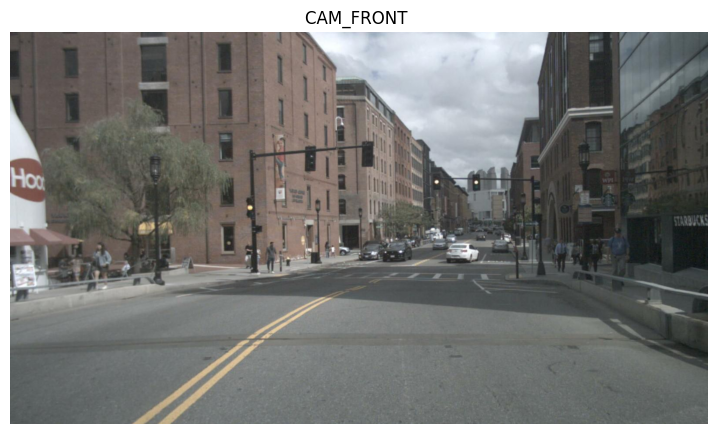


Rendering with annotations...


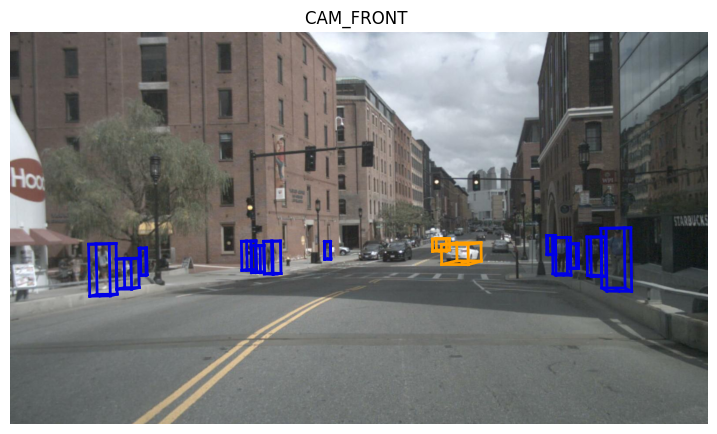

In [50]:
from nuscenes.nuscenes import NuScenes

# ---- CONFIGURATION ----
scene_index = 1          # Change this to any scene index (e.g., 0 to 849)
sample_index = 0        # Change this to any sample index within the scene
camera_channel = 'CAM_FRONT'  # e.g., 'CAM_FRONT', 'CAM_BACK', 'CAM_FRONT_LEFT', etc.

# ---- LOAD SCENE AND TRAVERSE TO SAMPLE ----
scene = nusc.scene[scene_index]
sample_token = scene['first_sample_token']

# Traverse to the target sample
for _ in range(sample_index):
    sample = nusc.get('sample', sample_token)
    if not sample['next']:
        raise ValueError(f"Scene {scene_index} has fewer than {sample_index + 1} samples.")
    sample_token = sample['next']

# ---- GET SAMPLE AND DATA TOKEN FOR CAMERA ----
sample = nusc.get('sample', sample_token)

if camera_channel not in sample['data']:
    raise ValueError(f"Camera channel '{camera_channel}' not found in sample.")

cam_token = sample['data'][camera_channel]

# ---- RENDER IMAGE WITHOUT ANNOTATIONS ----
print("\nRendering without annotations...")
nusc.render_sample_data(cam_token, with_anns=False)

# ---- RENDER IMAGE WITH ANNOTATIONS ----
print("\nRendering with annotations...")
nusc.render_sample_data(cam_token, with_anns=True)


In [30]:
from collections import Counter

# ---- CONFIGURATION ----
target_index = 1  # Change this to check any sample index 

# ---- SCENE & SAMPLE SELECTION ----
scene = nusc.scene[1]  # Scene 01 (index 1 in nusc.scene)
sample_token = scene['first_sample_token']

# Traverse to the target sample index
for i in range(target_index):
    sample = nusc.get('sample', sample_token)
    if not sample['next']:
        raise ValueError(f"Scene has fewer than {target_index + 1} samples.")
    sample_token = sample['next']

# Load the target sample
target_sample = nusc.get('sample', sample_token)

# ---- ANNOTATION PROCESSING ----
annotation_tokens = target_sample['anns']
print(f"\nSample {target_index + 1}:")
print(f"Token: {sample_token}")
print(f"Number of annotations: {len(annotation_tokens)}")

# Count object categories
categories = [nusc.get('sample_annotation', ann_token)['category_name'] for ann_token in annotation_tokens]
category_counts = Counter(categories)

# ---- CATEGORY DISTRIBUTION ----
print("\n--- Object Category Distribution ---")
for category, count in category_counts.items():
    print(f"{category}: {count} instance(s)")

# ---- BALANCE CHECK ----
print("\nData balanced check:")
max_count = max(category_counts.values())
min_count = min(category_counts.values())
total_annotations = len(annotation_tokens)

if max_count + min_count == total_annotations:
    print(f"Balance condition met. Max count: {max_count}, Min count: {min_count}")
    print(f"Balance ratio: {max_count / max(min_count, 1):.2f}")
else:
    print(f"Balance condition not met. Max + Min = {max_count + min_count}, Total annotations = {total_annotations}")

# ---- INTERPRETATION ----
print("\n--- Interpretation ---")
dominant_class = category_counts.most_common(1)[0]
print(f"Most dominant class: {dominant_class[0]} ({dominant_class[1]} instances)")

# Define safety-critical classes
critical_classes = [
    'human.pedestrian.adult', 'human.pedestrian.child', 'human.pedestrian.wheelchair',
    'human.pedestrian.stroller', 'human.pedestrian.personal_mobility',
    'human.pedestrian.police_officer', 'human.pedestrian.construction_worker',
    'vehicle.bicycle', 'vehicle.motorcycle'
]

print("\nSafety-critical class presence:")
for cls in critical_classes:
    count = category_counts.get(cls, 0)
    print(f"  {'✓' if count > 0 else '✗'} {cls}: {count}")

# Safety-critical object ratio
critical_total = sum(category_counts.get(cls, 0) for cls in critical_classes)
if critical_total / total_annotations < 0.3:
    print("\n⚠️ Warning: Safety-critical objects are underrepresented (<30% of annotations).")
else:
    print("\n✅ Safety-critical object representation is sufficient.")




Sample 2:
Token: 3950bd41f74548429c0f7700ff3d8269
Number of annotations: 30

--- Object Category Distribution ---
human.pedestrian.adult: 23 instance(s)
vehicle.car: 7 instance(s)

Data balanced check:
Balance condition met. Max count: 23, Min count: 7
Balance ratio: 3.29

--- Interpretation ---
Most dominant class: human.pedestrian.adult (23 instances)

Safety-critical class presence:
  ✓ human.pedestrian.adult: 23
  ✗ human.pedestrian.child: 0
  ✗ human.pedestrian.wheelchair: 0
  ✗ human.pedestrian.stroller: 0
  ✗ human.pedestrian.personal_mobility: 0
  ✗ human.pedestrian.police_officer: 0
  ✗ human.pedestrian.construction_worker: 0
  ✗ vehicle.bicycle: 0
  ✗ vehicle.motorcycle: 0

✅ Safety-critical object representation is sufficient.
